In [2]:
!pip install python-dotenv


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install tiktoken

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import torch

In [3]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers import AutoTokenizer, AutoModelForSequenceClassification

In [4]:
from dotenv import load_dotenv
load_dotenv()
import os
access_token = os.getenv('HF_TOKEN')

In [5]:
model_name = "microsoft/deberta-v3-base"

In [6]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Add use_safetensors=True to bypass the security error
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=10,
    use_safetensors=True 
)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.bias                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.weight        

In [7]:
tokenizer.save_pretrained(f"/filed_classification_models_for_software_project/tokenizer/{model_name}")
model.save_pretrained(f"/filed_classification_models_for_software_project/model/{model_name}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [8]:
import pandas as pd

In [9]:


# Load your merged file
df = pd.read_csv('D:/SoftwareProject/3_fileds_using_api/3filds/final_dataset.csv')

# Combine Title and Abstract for the model to read
# We'll fill empty abstracts with an empty string to avoid errors
df['input_text'] = df['title'].fillna('') + ". " + df['abstract'].fillna('')

print(f"Loaded {len(df)} rows of research metadata.")

Loaded 24015 rows of research metadata.


In [10]:
df.head()




,title,abstract,field_1_na,field_1_co,field_2_na,field_2_co,field_3_na,field_3_co,source_file,input_text
0,Discontinuities between maternity and child an...,BackgroundContinuity in the context of healthc...,"Public Health, Environmental and Occupational ...",45.00%,Health (social science),35.00%,Nursing (miscellaneous),20.00%,output2.csv,Discontinuities between maternity and child an...
1,An interactive decision-making framework (i-DM...,Background Low numbers of women in Queensland ...,Health Policy,45.00%,"Public Health, Environmental and Occupational ...",35.00%,Ecology,20.00%,output2.csv,An interactive decision-making framework (i-DM...
2,Midwifery-led care can lower caesarean section...,INTRODUCTION Midwifery-led care is recognised ...,Ecology,85.00%,"Public Health, Environmental and Occupational ...",10.00%,Maternity and Midwifery,5.00%,output2.csv,Midwifery-led care can lower caesarean section...
3,The association between midwifery staffing lev...,Background Women have consistently reported lo...,Nursing (miscellaneous),70.00%,"Public Health, Environmental and Occupational ...",20.00%,Health Policy,10.00%,output2.csv,The association between midwifery staffing lev...
4,Competencies for respectful maternity care: Id...,"BACKGROUND\nA respectful, person-centered phil...",Nursing (miscellaneous),70.00%,"Public Health, Environmental and Occupational ...",20.00%,Ecology,10.00%,output2.csv,Competencies for respectful maternity care: Id...


In [11]:
# List all column names
print(df.columns)

Index(['title', 'abstract', 'field_1_na', 'field_1_co', 'field_2_na',
       'field_2_co', 'field_3_na', 'field_3_co', 'source_file', 'input_text'],
      dtype='object')


In [12]:
print(df.dtypes)


title          object
abstract       object
field_1_na     object
field_1_co     object
field_2_na     object
field_2_co     object
field_3_na     object
field_3_co     object
source_file    object
input_text     object
dtype: object


In [13]:
# Select the last row (-1) and the first column (0)
print(df.iloc[0, -1])

Discontinuities between maternity and child and family health services: health professional’s perceptions. BackgroundContinuity in the context of healthcare refers to the perception of the client that care has been connected and coherent over time. For over a decade professionals providing maternity and child and family health (CFH) services in Australia and internationally have emphasised the importance of continuity of care for women, families and children. However, continuity across maternity and CFH services remains elusive. Continuity is defined and implemented in different ways, resulting in fragmentation of care particularly at points of transition from one service or professional to another.This paper examines the concept of continuity across the maternity and CFH service continuum from the perspectives of midwifery, CFH nursing, general practitioner (GP) and practice nurse (PN) professional leaders.MethodsData were collected as part of a three phase mixed methods study investi

In [14]:
# Stack the columns, remove duplicates, and get the final count
total_unique = pd.concat([df['field_1_na'], df['field_2_na'], df['field_3_na']]).nunique()
print(f"Total unique research fields across all columns: {total_unique}")

Total unique research fields across all columns: 431


In [15]:
import pandas as pd

# 1. Combine the three field columns into one long Series
all_fields_combined = pd.concat([df['field_1_na'], df['field_2_na'], df['field_3_na']])

# 2. Get unique values and convert to a sorted list for consistency
unique_fields_list = sorted(all_fields_combined.dropna().unique().tolist())

# Verify the length matches your count
print(f"Total Unique Fields: {len(unique_fields_list)}")

Total Unique Fields: 431


In [16]:
print(unique_fields_list)


['Accounting', 'Acoustics and Ultrasonics', 'Aerospace Engineering', 'Aging', 'Agricultural and Biological Sciences (miscellaneous)', 'Agronomy and Crop Science', 'Algebra and Number Theory', 'Algebraic Topology,', 'Allergy,', 'Analysis', 'Analytical Chemistry', 'Anatomy', 'Anesthesiology and Pain Medicine', 'Animal Science and Zoology', 'Anthropology', 'Applied Mathematics', 'Applied Psychology', 'Aquaculture,', 'Aquatic Science', 'Archeology', 'Archeology (arts and humanities)', 'Architecture', 'Artificial Intelligence', 'Arts and Humanities (miscellaneous)', 'Assessment and Diagnosis', 'Astronomy and Astrophysics', 'Astrophysics and Cosmology,', 'Astrophysics of Galaxies,', 'Astrophysics,', 'Atmospheric Science', 'Atomic and Molecular Physics,', 'Atomic and Molecular Physics, and Optics', 'Audiology,', 'Automotive Engineering', 'Behavioral Neuroscience', 'Bibliometrics,', 'Biochemistry', 'Biochemistry, Genetics and Molecular Biology (miscellaneous)', 'Bioengineering', 'Bioethics,', 

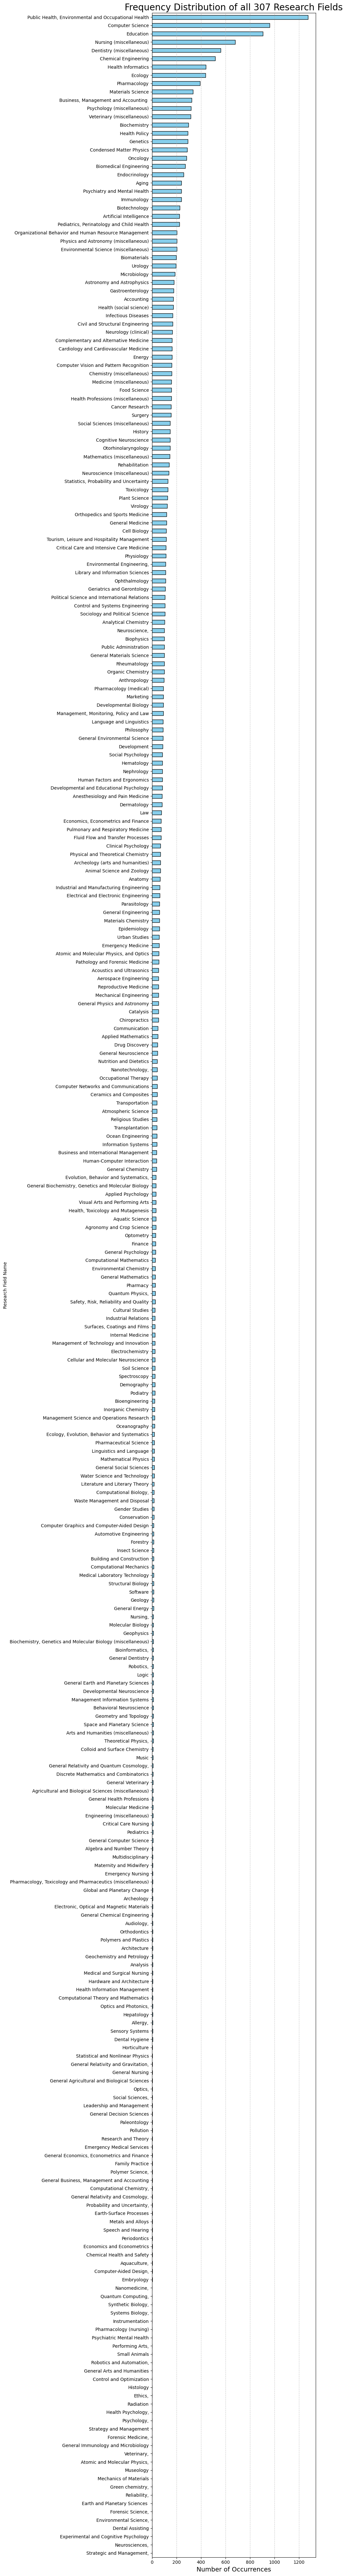

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Combine all three field columns to get the total count for every field
all_fields = pd.concat([df['field_1_na']])

# 2. Calculate the frequency of each field
field_counts = all_fields.value_counts()

# 3. Create a very tall figure (10 inches wide, 80 inches tall) 
# to ensure all 431 labels are visible and don't overlap
plt.figure(figsize=(10, 80))

# 4. Plot as a horizontal bar chart
field_counts.plot(kind='barh', color='skyblue', edgecolor='black')

# 5. Add titles and labels
plt.title(f'Frequency Distribution of all {len(field_counts)} Research Fields', fontsize=20)
plt.xlabel('Number of Occurrences', fontsize=14)
plt.ylabel('Research Field Name', fontsize=10)

# 6. Invert y-axis so the highest frequency is at the top
plt.gca().invert_yaxis()

# 7. Add a grid for easier reading
plt.grid(axis='x', linestyle='--', alpha=0.7)

# 8. Adjust layout to prevent clipping
plt.tight_layout()

# Save the plot as a high-resolution image so you can zoom in and inspect it
plt.savefig('all_fields_distribution.png', dpi=300)

# Display the plot in the notebook
plt.show()

In [18]:
import pandas as pd
import numpy as np
import torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# --- 1. Clean Confidence Scores (Fixes the ValueError) ---
conf_cols = ['field_1_co', 'field_2_co', 'field_3_co']
for col in conf_cols:
    # Remove % sign, convert to float, and normalize to 0.0-1.0
    df[col] = df[col].astype(str).str.replace('%', '').astype(float) / 100.0

# --- 2. Create Label Mappings ---
unique_labels = sorted(df['field_1_na'].unique().tolist())
label2id = {label: i for i, label in enumerate(unique_labels)}
id2label = {i: label for i, label in enumerate(unique_labels)}
num_labels = len(unique_labels)

# --- 3. Create Multi-Label Matrix ---
def create_label_matrix(row):
    matrix = np.zeros(num_labels, dtype=np.float32)
    for i in range(1, 4):
        f_name = row[f'field_{i}_na']
        f_score = row[f'field_{i}_co']
        if pd.notna(f_name) and f_name in label2id:
            matrix[label2id[f_name]] = float(f_score)
    return matrix

df['labels'] = df.apply(create_label_matrix, axis=1).tolist()
df['input_text'] = "Title: " + df['title'].fillna("") + " [SEP] Abstract: " + df['abstract'].fillna("")

# --- 4. Dataset Split (80/20) ---
raw_ds = Dataset.from_pandas(df[['input_text', 'labels']])
dataset = raw_ds.train_test_split(test_size=0.2, seed=42)

In [20]:
model_nm = "microsoft/deberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(model_nm)

def tokenize_func(examples):
    return tokenizer(examples["input_text"], truncation=True, padding="max_length", max_length=512)

tokenized_ds = dataset.map(tokenize_func, batched=True)

model = AutoModelForSequenceClassification.from_pretrained(
    model_nm,
    num_labels=num_labels,
    problem_type="multi_label_classification",
    ignore_mismatched_sizes=True,
    use_safetensors=True
)

Map:   0%|          | 0/19212 [00:00<?, ? examples/s]

Map:   0%|          | 0/4803 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.bias                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.weight        

In [21]:
import torch
print(f"Is GPU available? {torch.cuda.is_available()}")
print(f"Current Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

Is GPU available? True
Current Device: NVIDIA GeForce RTX 4050 Laptop GPU


In [23]:
from transformers import TrainingArguments, Trainer

# Your arguments should work now since we fixed eval_strategy
args = TrainingArguments(
    output_dir='research_classifier_output',
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4, 
    per_device_eval_batch_size=4,
    num_train_epochs=5,
    weight_decay=0.01,
    bf16=True,           
    fp16=False,           
    load_best_model_at_end=True,
    logging_steps=10
)

# Update 'tokenizer' to 'processing_class' here
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_ds['train'],
    eval_dataset=tokenized_ds['test'],
    processing_class=tokenizer, # Changed from 'tokenizer' to 'processing_class'
)

# NOW RUN THE PROCESS
trainer.train()2

Epoch,Training Loss,Validation Loss
1,0.000000,nan
2,0.000000,nan
3,0.000000,nan
4,0.000000,nan
5,0.000000,nan


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=24015, training_loss=0.0001630396885646524, metrics={'train_runtime': 9949.0549, 'train_samples_per_second': 9.655, 'train_steps_per_second': 2.414, 'total_flos': 2.534411461220352e+16, 'train_loss': 0.0001630396885646524, 'epoch': 5.0})

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Get predictions from the test set
predictions = trainer.predict(tokenized_ds['test'])
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

# 2. Create the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Plot using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix: Research Metadata Classifier')
plt.show()

ValueError: Classification metrics can't handle a mix of continuous-multioutput and binary targets